In [2]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)

RANDOM_STATE = 42  

In [4]:
df = pd.read_csv("C:\\Users\\Yatri\\Desktop\\ml_lab05\\productivity+prediction+of+garment+employees\\garments_worker_productivity.csv")  # update path if needed
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [56]:
df[["idle_time", "idle_men", "no_of_style_change", "wip", "over_time"]].describe()

,idle_time,idle_men,no_of_style_change,wip,over_time
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000
mean,0.730159,0.369256,0.150376,1190.465991,4567.460317
std,12.709757,3.268987,0.427848,1837.455001,3348.823563
min,0.000000,0.000000,0.000000,7.000000,0.000000
25%,0.000000,0.000000,0.000000,774.500000,1440.000000
50%,0.000000,0.000000,0.000000,1039.000000,3960.000000
75%,0.000000,0.000000,0.000000,1252.500000,6960.000000
max,300.000000,45.000000,2.000000,23122.000000,25920.000000


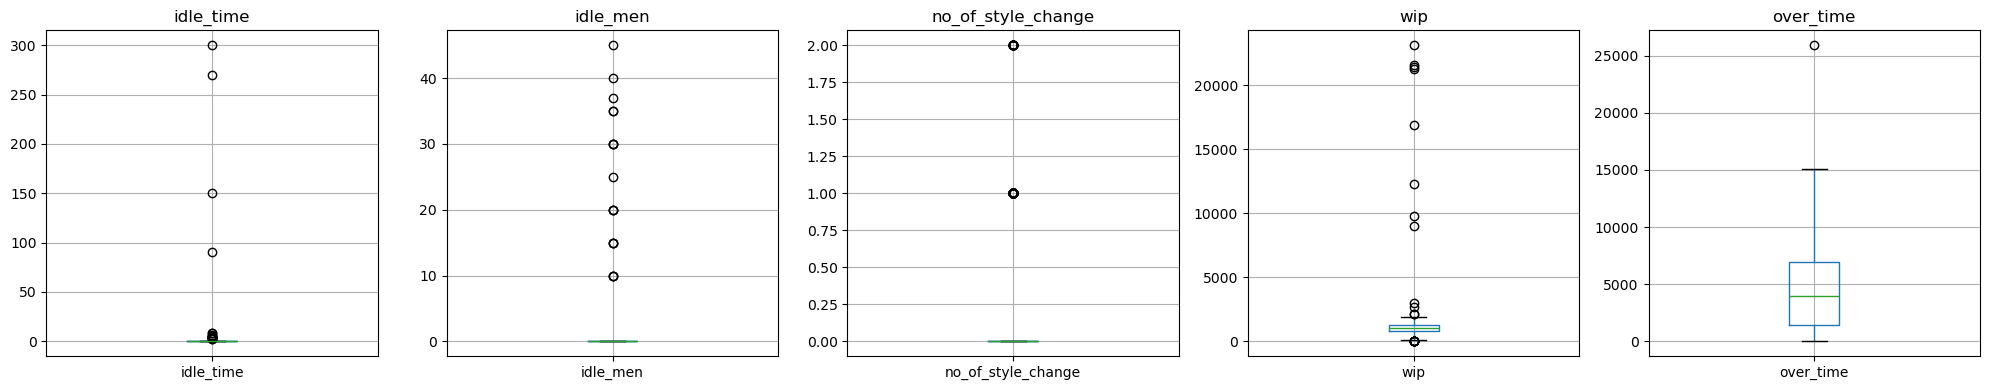

idle_time: 18 outliers out of 1197 rows (1.5%)
idle_men: 18 outliers out of 1197 rows (1.5%)
no_of_style_change: 147 outliers out of 1197 rows (12.3%)
wip: 22 outliers out of 1197 rows (1.8%)
over_time: 1 outliers out of 1197 rows (0.1%)


In [57]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, ["idle_time", "idle_men", "no_of_style_change", "wip", "over_time"]):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# IQR-based outlier count per column (diagnostic only - not auto-dropping anything)
for col in ["idle_time", "idle_men", "no_of_style_change", "wip", "over_time"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers out of {len(df)} rows ({n_outliers/len(df)*100:.1f}%)")

In [9]:
# Fix the "sweing" typo + stray trailing whitespace in department
df["department"] = df["department"].str.strip().replace({"sweing": "sewing"})

# date is redundant with quarter + day, which already carry the temporal signal
df = df.drop(columns=["date"])

# actual_productivity has a few values slightly above 1.0 despite being a 0-1 metric
df["actual_productivity"] = df["actual_productivity"].clip(upper=1.0)

df.isnull().sum()  # sanity check -> only wip should show missing values

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [10]:
# Do this BEFORE splitting so both train and test get a consistent label
df["MeetsTarget"] = (df["actual_productivity"] >= df["targeted_productivity"]).astype(int)

df["MeetsTarget"].value_counts(normalize=True)  # confirms the ~73/27 imbalance

MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

In [11]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["MeetsTarget"]   # preserve class ratio in both splits
)
train_df, test_df = df.loc[train_idx], df.loc[test_idx]

In [30]:
cat_cols = ["quarter", "department", "day", "team"]   # nominal -> one-hot
num_cols = ["targeted_productivity", "smv", "wip", "over_time",
            "incentive", "idle_time", "idle_men",
            "no_of_style_change", "no_of_workers"]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),  # wip is structurally missing for "finishing"
    ("scale", StandardScaler())                     # linear models are scale-sensitive
])
categorical_pipe = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

In [31]:
X_train_processed = preprocessor.fit_transform(X_train_reg)
X_test_processed = preprocessor.transform(X_test_reg)

In [38]:
# --- Warm-up call (not timed) ---
_ = LinearRegression().fit(X_train_processed, y_train_reg)

# --- Actual timed runs, averaged ---
n_trials = 10
train_times = []
predict_times = []

for _ in range(n_trials):
    lin_model = LinearRegression()

    t0 = time.perf_counter()
    lin_model.fit(X_train_processed, y_train_reg)
    train_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    y_pred_reg = lin_model.predict(X_test_processed)
    predict_times.append(time.perf_counter() - t0)

train_time_reg = np.median(train_times)
predict_time_reg = np.median(predict_times)

print(f"train_time_reg={train_time_reg:.6f}s  predict_time_reg={predict_time_reg:.6f}s")

train_time_reg=0.051366s  predict_time_reg=0.000234s


In [14]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
print(f"train_time={train_time_reg:.6f}s  predict_time={predict_time_reg:.6f}s")

MAE=0.1079  RMSE=0.1423  R2=0.2924
train_time=0.191683s  predict_time=0.005409s


In [39]:
# --- Warm-up call (not timed) ---
_ = LogisticRegression(max_iter=1000).fit(X_train_processed, y_train_clf)

# --- Actual timed runs, averaged ---
train_times, predict_times = [], []
for _ in range(n_trials):
    log_model = LogisticRegression(max_iter=1000)

    t0 = time.perf_counter()
    log_model.fit(X_train_processed, y_train_clf)
    train_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    y_pred_clf = log_model.predict(X_test_processed)
    predict_times.append(time.perf_counter() - t0)

train_time_clf = np.median(train_times)
predict_time_clf = np.median(predict_times)

print(f"train_time_clf={train_time_clf:.6f}s  predict_time_clf={predict_time_clf:.6f}s")

train_time_clf=0.022082s  predict_time_clf=0.000282s


In [40]:
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)     # keep an eye on this given the class imbalance
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(f"train_time={train_time_clf:.6f}s  predict_time={predict_time_clf:.6f}s")

Accuracy=0.6833  Precision=0.7647  Recall=0.8171  F1=0.7901
train_time=0.022082s  predict_time=0.000282s


In [41]:
results_sklearn = {
    "regression": {"MAE": mae, "RMSE": rmse, "R2": r2,
                   "train_time": train_time_reg, "predict_time": predict_time_reg},
    "classification": {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1,
                        "train_time": train_time_clf, "predict_time": predict_time_clf}
}
results_sklearn

{'regression': {'MAE': 0.10791464894741698,
  'RMSE': np.float64(0.14225417456270387),
  'R2': 0.2923715693904946,
  'train_time': np.float64(0.051365649997023866),
  'predict_time': np.float64(0.00023425000836141407)},
 'classification': {'Accuracy': 0.6833333333333333,
  'Precision': 0.7647058823529411,
  'Recall': 0.8171428571428572,
  'F1': 0.7900552486187845,
  'train_time': np.float64(0.022082150011556223),
  'predict_time': np.float64(0.000281700020423159)}}

## Part B

In [18]:
# Compute the median from TRAIN only, then apply it to both train and test.
# Fitting on train-only avoids leaking test-set information into preprocessing.
wip_median = train_df["wip"].median()

train_df = train_df.copy()
test_df = test_df.copy()
train_df["wip"] = train_df["wip"].fillna(wip_median)
test_df["wip"] = test_df["wip"].fillna(wip_median)

In [19]:
cat_cols = ["quarter", "department", "day", "team"]
num_cols = ["targeted_productivity", "smv", "wip", "over_time",
            "incentive", "idle_time", "idle_men",
            "no_of_style_change", "no_of_workers"]

# pd.get_dummies is pandas, not sklearn -> allowed under the "no sklearn utilities" rule
train_ohe = pd.get_dummies(train_df[cat_cols], columns=cat_cols, drop_first=True)
test_ohe = pd.get_dummies(test_df[cat_cols], columns=cat_cols, drop_first=True)

# Test set might not contain every category seen in train (or vice versa) ->
# align columns so both matrices have identical shape/order before modeling.
train_ohe, test_ohe = train_ohe.align(test_ohe, join="left", axis=1, fill_value=0)

In [20]:
train_num = train_df[num_cols]
test_num = test_df[num_cols]

mu = train_num.mean()
sigma = train_num.std()

train_num_scaled = (train_num - mu) / sigma
test_num_scaled = (test_num - mu) / sigma

In [21]:
# Combine scaled numeric + encoded categorical features
X_train_full = pd.concat([train_num_scaled, train_ohe], axis=1).astype(float)
X_test_full = pd.concat([test_num_scaled, test_ohe], axis=1).astype(float)

def add_intercept(X):
    # Manually prepend a column of 1s -> sklearn's fit_intercept did this
    # automatically in Part A; here we must do it ourselves.
    return np.hstack([np.ones((X.shape[0], 1)), X.values])

y_train_reg = train_df["actual_productivity"].values
y_test_reg = test_df["actual_productivity"].values

In [22]:
# Regression uses ALL features including targeted_productivity
X_train_reg_mat = add_intercept(X_train_full)
X_test_reg_mat = add_intercept(X_test_full)

t0 = time.perf_counter()
# Normal equation solved via pseudo-inverse (SVD-based) -> robust even if
# X^T X is singular/ill-conditioned (e.g. from one-hot collinearity)
theta_reg = np.linalg.pinv(X_train_reg_mat) @ y_train_reg
train_time_reg_scratch = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_reg_scratch = X_test_reg_mat @ theta_reg
predict_time_reg_scratch = time.perf_counter() - t0

In [23]:
def mae_manual(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse_manual(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mae_scratch = mae_manual(y_test_reg, y_pred_reg_scratch)
rmse_scratch = rmse_manual(y_test_reg, y_pred_reg_scratch)
r2_scratch = r2_manual(y_test_reg, y_pred_reg_scratch)

print(f"MAE={mae_scratch:.4f}  RMSE={rmse_scratch:.4f}  R2={r2_scratch:.4f}")

MAE=0.1079  RMSE=0.1423  R2=0.2924


In [24]:
clf_cols_num = [c for c in num_cols]  # actual_productivity was never in num_cols, so no leakage risk here
X_train_clf_mat = add_intercept(X_train_full)
X_test_clf_mat = add_intercept(X_test_full)

y_train_clf = train_df["MeetsTarget"].values
y_test_clf = test_df["MeetsTarget"].values

def sigmoid(z):
    # Clip z to avoid overflow in np.exp for very negative/positive values
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [25]:
def train_logistic_gd(X, y, lr=0.1, n_iters=2000, tol=1e-7):
    n, d = X.shape
    theta = np.zeros(d)
    losses = []

    for i in range(n_iters):
        z = X @ theta
        preds = sigmoid(z)

        # Binary cross-entropy loss (with small epsilon to avoid log(0))
        eps = 1e-12
        loss = -np.mean(y * np.log(preds + eps) + (1 - y) * np.log(1 - preds + eps))
        losses.append(loss)

        # Vectorized gradient of log-loss w.r.t. theta
        grad = (1 / n) * (X.T @ (preds - y))
        theta -= lr * grad

        # Stop early once the loss stops meaningfully improving
        if i > 0 and abs(losses[-2] - losses[-1]) < tol:
            break

    return theta, losses

t0 = time.perf_counter()
theta_clf, loss_history = train_logistic_gd(X_train_clf_mat, y_train_clf, lr=0.1, n_iters=2000)
train_time_clf_scratch = time.perf_counter() - t0

print(f"Converged after {len(loss_history)} iterations, final loss={loss_history[-1]:.4f}")

Converged after 2000 iterations, final loss=0.4656


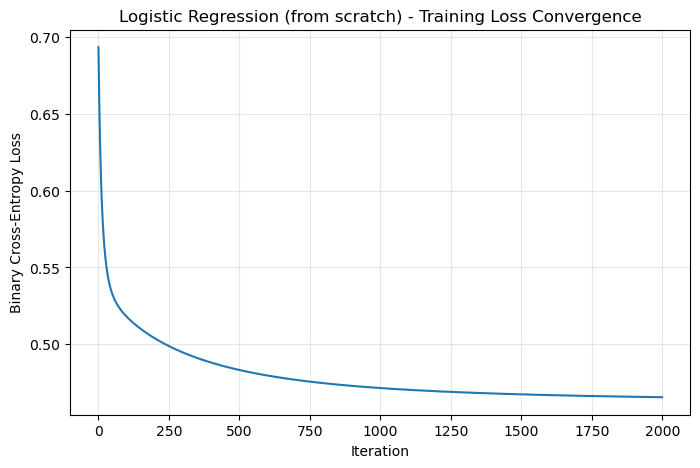

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression (from scratch) - Training Loss Convergence")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
t0 = time.perf_counter()
probs_test = sigmoid(X_test_clf_mat @ theta_clf)
y_pred_clf_scratch = (probs_test >= 0.5).astype(int)
predict_time_clf_scratch = time.perf_counter() - t0

def accuracy_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_manual(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_manual(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_manual(y_true, y_pred):
    p, r = precision_manual(y_true, y_pred), recall_manual(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

acc_scratch = accuracy_manual(y_test_clf, y_pred_clf_scratch)
prec_scratch = precision_manual(y_test_clf, y_pred_clf_scratch)
rec_scratch = recall_manual(y_test_clf, y_pred_clf_scratch)
f1_scratch = f1_manual(y_test_clf, y_pred_clf_scratch)

print(f"Accuracy={acc_scratch:.4f}  Precision={prec_scratch:.4f}  "
      f"Recall={rec_scratch:.4f}  F1={f1_scratch:.4f}")

Accuracy=0.6875  Precision=0.7632  Recall=0.8286  F1=0.7945


In [28]:
results_scratch = {
    "regression": {"MAE": mae_scratch, "RMSE": rmse_scratch, "R2": r2_scratch,
                   "train_time": train_time_reg_scratch, "predict_time": predict_time_reg_scratch},
    "classification": {"Accuracy": acc_scratch, "Precision": prec_scratch,
                        "Recall": rec_scratch, "F1": f1_scratch,
                        "train_time": train_time_clf_scratch, "predict_time": predict_time_clf_scratch}
}
results_scratch

{'regression': {'MAE': np.float64(0.10791464894741691),
  'RMSE': np.float64(0.1422541745627039),
  'R2': np.float64(0.29237156939049413),
  'train_time': 0.06693010003073141,
  'predict_time': 6.370001938194036e-05},
 'classification': {'Accuracy': np.float64(0.6875),
  'Precision': np.float64(0.7631578947368421),
  'Recall': np.float64(0.8285714285714286),
  'F1': np.float64(0.7945205479452055),
  'train_time': 0.222999699995853,
  'predict_time': 0.0003117000451311469}}

In [42]:
rows = []

for metric in ["MAE", "RMSE", "R2"]:
    rows.append({
        "Task": "Regression", "Metric": metric,
        "Scikit-learn": results_sklearn["regression"][metric],
        "From Scratch": results_scratch["regression"][metric],
    })

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    rows.append({
        "Task": "Classification", "Metric": metric,
        "Scikit-learn": results_sklearn["classification"][metric],
        "From Scratch": results_scratch["classification"][metric],
    })

# Timing rows kept separate since they're not accuracy metrics
for task in ["regression", "classification"]:
    for t in ["train_time", "predict_time"]:
        rows.append({
            "Task": task.capitalize(), "Metric": t,
            "Scikit-learn": results_sklearn[task][t],
            "From Scratch": results_scratch[task][t],
        })

comparison_df = pd.DataFrame(rows)

# Compute the gap so you can immediately see where Part C should focus
comparison_df["Diff (Scratch - Sklearn)"] = (
    comparison_df["From Scratch"] - comparison_df["Scikit-learn"]
)
comparison_df["% Diff"] = (
    comparison_df["Diff (Scratch - Sklearn)"] / comparison_df["Scikit-learn"].abs() * 100
).round(2)

comparison_df

,Task,Metric,Scikit-learn,From Scratch,Diff (Scratch - Sklearn),% Diff
0,Regression,MAE,0.107915,0.107915,-6.938894e-17,-0.00
1,Regression,RMSE,0.142254,0.142254,2.775558e-17,0.00
2,Regression,R2,0.292372,0.292372,-4.440892e-16,-0.00
3,Classification,Accuracy,0.683333,0.687500,4.166667e-03,0.61
4,Classification,Precision,0.764706,0.763158,-1.547988e-03,-0.20
5,Classification,Recall,0.817143,0.828571,1.142857e-02,1.40
6,Classification,F1,0.790055,0.794521,4.465299e-03,0.57
7,Regression,train_time,0.051366,0.066930,1.556445e-02,30.30
8,Regression,predict_time,0.000234,0.000064,-1.705500e-04,-72.81
9,Classification,train_time,0.022082,0.223000,2.009175e-01,909.86


## part C

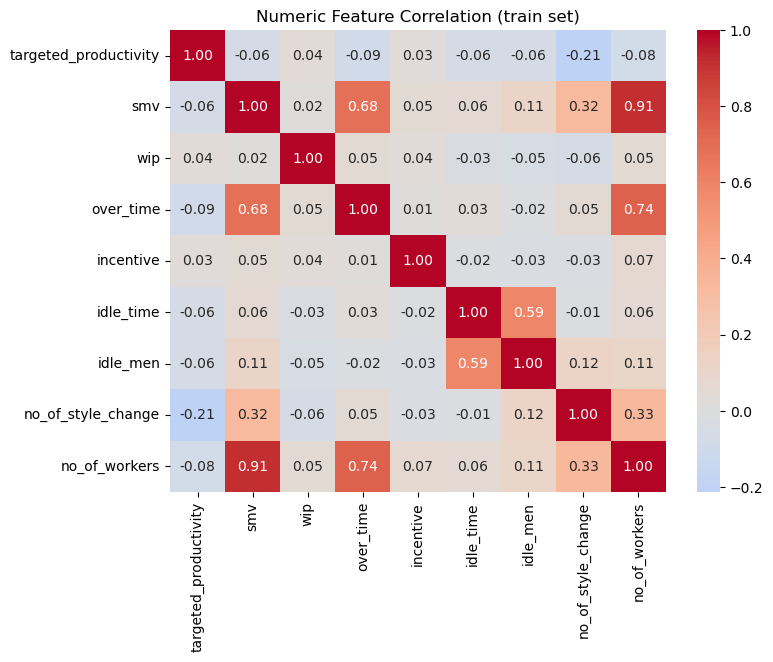

Highly correlated pairs (|corr| > 0.7):
('smv', 'no_of_workers', np.float64(0.9145518025355642))
('over_time', 'no_of_workers', np.float64(0.7436302080652694))


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation (train set)")
plt.show()

# Flag any pair with |correlation| above 0.7 -> candidates for dropping one of the two
high_corr_pairs = [
    (num_cols[i], num_cols[j], corr_matrix.iloc[i, j])
    for i in range(len(num_cols))
    for j in range(i + 1, len(num_cols))
    if abs(corr_matrix.iloc[i, j]) > 0.7
]
print("Highly correlated pairs (|corr| > 0.7):")
for pair in high_corr_pairs:
    print(pair)

In [44]:
for col_a, col_b, corr_ab in high_corr_pairs:
    corr_a_target = train_df[[col_a, "actual_productivity"]].corr().iloc[0, 1]
    corr_b_target = train_df[[col_b, "actual_productivity"]].corr().iloc[0, 1]
    print(f"{col_a} vs {col_b}: corr={corr_ab:.3f}")
    print(f"  {col_a} vs target: {corr_a_target:.3f}")
    print(f"  {col_b} vs target: {corr_b_target:.3f}")
    weaker = col_a if abs(corr_a_target) < abs(corr_b_target) else col_b
    print(f"  -> drop candidate: {weaker}\n")

smv vs no_of_workers: corr=0.915
  smv vs target: -0.124
  no_of_workers vs target: -0.061
  -> drop candidate: no_of_workers

over_time vs no_of_workers: corr=0.744
  over_time vs target: -0.053
  no_of_workers vs target: -0.061
  -> drop candidate: over_time



In [45]:
redundant_num_col = "no_of_workers"

num_cols_reduced = [c for c in num_cols if c != redundant_num_col]
print(num_cols_reduced)

['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change']


In [46]:
feature_names = ["intercept"] + list(X_train_full.columns)
coef_df = pd.DataFrame({
    "feature": feature_names,
    "abs_coef": np.abs(theta_clf)
}).sort_values("abs_coef", ascending=False)

print(coef_df.to_string(index=False))

team_cols = [c for c in coef_df["feature"] if c.startswith("team_")]
non_team_cols = [c for c in coef_df["feature"] if c != "intercept" and c not in team_cols]

print(f"\nMax |coef| among team_* columns : {coef_df[coef_df['feature'].isin(team_cols)]['abs_coef'].max():.4f}")
print(f"Max |coef| among all other features: {coef_df[coef_df['feature'].isin(non_team_cols)]['abs_coef'].max():.4f}")
print(f"Mean |coef| for team_*            : {coef_df[coef_df['feature'].isin(team_cols)]['abs_coef'].mean():.4f}")
print(f"Mean |coef| for other features     : {coef_df[coef_df['feature'].isin(non_team_cols)]['abs_coef'].mean():.4f}")

              feature  abs_coef
        no_of_workers  1.216122
    department_sewing  1.150172
                  smv  1.143932
               team_3  0.876807
                  wip  0.847830
               team_9  0.830189
               team_8  0.801843
            intercept  0.703209
               team_7  0.591074
              team_12  0.565825
     quarter_Quarter5  0.561018
               team_4  0.537971
              team_11  0.530700
              team_10  0.506659
          day_Tuesday  0.492951
         day_Thursday  0.446940
             idle_men  0.341403
     quarter_Quarter3  0.326807
               team_6  0.306197
        day_Wednesday  0.272090
               team_2  0.229440
     quarter_Quarter2  0.163752
            incentive  0.159017
   no_of_style_change  0.155093
           day_Sunday  0.120578
               team_5  0.117325
            over_time  0.080898
targeted_productivity  0.072703
            idle_time  0.037057
         day_Saturday  0.033228
     qua

In [48]:
drop_team=False

In [49]:
cat_cols_reduced = [c for c in cat_cols if not (drop_team and c == "team")]  # drop_team=False -> team is kept

train_ohe_r = pd.get_dummies(train_df[cat_cols_reduced], columns=cat_cols_reduced, drop_first=True)
test_ohe_r = pd.get_dummies(test_df[cat_cols_reduced], columns=cat_cols_reduced, drop_first=True)
train_ohe_r, test_ohe_r = train_ohe_r.align(test_ohe_r, join="left", axis=1, fill_value=0)

mu_r = train_df[num_cols_reduced].mean()
sigma_r = train_df[num_cols_reduced].std()
train_num_r = (train_df[num_cols_reduced] - mu_r) / sigma_r
test_num_r = (test_df[num_cols_reduced] - mu_r) / sigma_r

X_train_reduced = add_intercept(pd.concat([train_num_r, train_ohe_r], axis=1).astype(float))
X_test_reduced = add_intercept(pd.concat([test_num_r, test_ohe_r], axis=1).astype(float))

print(f"Reduced feature matrix shape: {X_train_reduced.shape}")

Reduced feature matrix shape: (957, 30)


In [50]:
def ridge_fit(X, y, lam):
    # Don't regularize the intercept -> zero out its penalty in the identity matrix
    d = X.shape[1]
    I = np.eye(d)
    I[0, 0] = 0
    return np.linalg.pinv(X.T @ X + lam * I) @ X.T @ y

lam = 1.0  # try a couple of values (0.1, 1, 10) and pick by test MAE/RMSE

t0 = time.perf_counter()
theta_ridge = ridge_fit(X_train_reduced, y_train_reg, lam)
train_time_reg_optimized = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_reg_optimized = X_test_reduced @ theta_ridge
predict_time_reg_optimized = time.perf_counter() - t0

mae_opt = mae_manual(y_test_reg, y_pred_reg_optimized)
rmse_opt = rmse_manual(y_test_reg, y_pred_reg_optimized)
r2_opt = r2_manual(y_test_reg, y_pred_reg_optimized)
print(f"Ridge -> MAE={mae_opt:.4f}  RMSE={rmse_opt:.4f}  R2={r2_opt:.4f}")

Ridge -> MAE=0.1103  RMSE=0.1441  R2=0.2741


In [51]:
def train_logistic_newton(X, y, n_iters=20, tol=1e-7):
    n, d = X.shape
    theta = np.zeros(d)
    losses = []

    for i in range(n_iters):
        z = X @ theta
        p = sigmoid(z)

        eps = 1e-12
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        losses.append(loss)

        grad = (1 / n) * (X.T @ (p - y))          # same gradient as GD
        S = p * (1 - p)                            # diagonal weights for the Hessian
        H = (1 / n) * (X.T * S) @ X                 # Hessian = (1/n) X^T S X

        # pinv guards against a near-singular Hessian (e.g. from correlated dummies)
        theta -= np.linalg.pinv(H) @ grad

        if i > 0 and abs(losses[-2] - losses[-1]) < tol:
            break

    return theta, losses

t0 = time.perf_counter()
theta_clf_newton, loss_history_newton = train_logistic_newton(X_train_reduced, y_train_clf)
train_time_clf_optimized = time.perf_counter() - t0

t0 = time.perf_counter()
probs_test_opt = sigmoid(X_test_reduced @ theta_clf_newton)
y_pred_clf_optimized = (probs_test_opt >= 0.5).astype(int)
predict_time_clf_optimized = time.perf_counter() - t0

print(f"Newton's method converged in {len(loss_history_newton)} iterations "
      f"(vs {len(loss_history)} for GD)")

acc_opt = accuracy_manual(y_test_clf, y_pred_clf_optimized)
prec_opt = precision_manual(y_test_clf, y_pred_clf_optimized)
rec_opt = recall_manual(y_test_clf, y_pred_clf_optimized)
f1_opt = f1_manual(y_test_clf, y_pred_clf_optimized)
print(f"Accuracy={acc_opt:.4f}  Precision={prec_opt:.4f}  Recall={rec_opt:.4f}  F1={f1_opt:.4f}")

Newton's method converged in 7 iterations (vs 2000 for GD)
Accuracy=0.6833  Precision=0.7647  Recall=0.8171  F1=0.7901


In [52]:
results_scratch_optimized = {
    "regression": {"MAE": mae_opt, "RMSE": rmse_opt, "R2": r2_opt,
                   "train_time": train_time_reg_optimized, "predict_time": predict_time_reg_optimized},
    "classification": {"Accuracy": acc_opt, "Precision": prec_opt, "Recall": rec_opt, "F1": f1_opt,
                        "train_time": train_time_clf_optimized, "predict_time": predict_time_clf_optimized}
}

rows = []
for metric in ["MAE", "RMSE", "R2"]:
    rows.append({"Task": "Regression", "Metric": metric,
                 "Scikit-learn": results_sklearn["regression"][metric],
                 "Scratch (baseline)": results_scratch["regression"][metric],
                 "Scratch (optimized)": results_scratch_optimized["regression"][metric]})
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    rows.append({"Task": "Classification", "Metric": metric,
                 "Scikit-learn": results_sklearn["classification"][metric],
                 "Scratch (baseline)": results_scratch["classification"][metric],
                 "Scratch (optimized)": results_scratch_optimized["classification"][metric]})
for task in ["regression", "classification"]:
    for t in ["train_time", "predict_time"]:
        rows.append({"Task": task.capitalize(), "Metric": t,
                     "Scikit-learn": results_sklearn[task][t],
                     "Scratch (baseline)": results_scratch[task][t],
                     "Scratch (optimized)": results_scratch_optimized[task][t]})

final_comparison_df = pd.DataFrame(rows)
final_comparison_df

,Task,Metric,Scikit-learn,Scratch (baseline),Scratch (optimized)
0,Regression,MAE,0.107915,0.107915,0.110293
1,Regression,RMSE,0.142254,0.142254,0.144075
2,Regression,R2,0.292372,0.292372,0.274141
3,Classification,Accuracy,0.683333,0.687500,0.683333
4,Classification,Precision,0.764706,0.763158,0.764706
5,Classification,Recall,0.817143,0.828571,0.817143
6,Classification,F1,0.790055,0.794521,0.790055
7,Regression,train_time,0.051366,0.066930,0.005990
8,Regression,predict_time,0.000234,0.000064,0.000081
9,Classification,train_time,0.022082,0.223000,0.030047


In [53]:
# Pick terms with a physical justification, not just throwing in every combination:
# - incentive x targeted_productivity: effect of incentive may depend on how ambitious the target is
# - smv^2: captures possible non-linear effect of task complexity on productivity
# - over_time x no_of_style_change: frequent style changes during overtime may compound disruption

train_feat = train_df[num_cols_reduced].copy()
test_feat = test_df[num_cols_reduced].copy()

for df_ in (train_feat, test_feat):
    df_["incentive_x_target"] = df_["incentive"] * df_["targeted_productivity"]
    df_["smv_sq"] = df_["smv"] ** 2
    df_["overtime_x_stylechange"] = df_["over_time"] * df_["no_of_style_change"]

num_cols_engineered = num_cols_reduced + ["incentive_x_target", "smv_sq", "overtime_x_stylechange"]
print(num_cols_engineered)

['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'incentive_x_target', 'smv_sq', 'overtime_x_stylechange']


In [54]:
# Scale the full engineered set together -> interaction terms have very different
# raw magnitudes (e.g. smv_sq vs incentive_x_target), so they need scaling too
mu_eng = train_feat[num_cols_engineered].mean()
sigma_eng = train_feat[num_cols_engineered].std()

train_num_eng = (train_feat[num_cols_engineered] - mu_eng) / sigma_eng
test_num_eng = (test_feat[num_cols_engineered] - mu_eng) / sigma_eng

# Reuse the same categorical encoding as before (team kept, since we decided not to drop it)
X_train_eng = add_intercept(pd.concat([train_num_eng, train_ohe_r], axis=1).astype(float))
X_test_eng = add_intercept(pd.concat([test_num_eng, test_ohe_r], axis=1).astype(float))

print(f"Engineered feature matrix shape: {X_train_eng.shape}")

Engineered feature matrix shape: (957, 33)


In [55]:
t0 = time.perf_counter()
theta_ols_engineered = np.linalg.pinv(X_train_eng) @ y_train_reg
train_time_reg_optimized = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_reg_optimized = X_test_eng @ theta_ols_engineered
predict_time_reg_optimized = time.perf_counter() - t0

mae_opt = mae_manual(y_test_reg, y_pred_reg_optimized)
rmse_opt = rmse_manual(y_test_reg, y_pred_reg_optimized)
r2_opt = r2_manual(y_test_reg, y_pred_reg_optimized)

print(f"OLS + interactions -> MAE={mae_opt:.4f}  RMSE={rmse_opt:.4f}  R2={r2_opt:.4f}")
print(f"Baseline was          MAE={mae_scratch:.4f}  RMSE={rmse_scratch:.4f}  R2={r2_scratch:.4f}")

OLS + interactions -> MAE=0.1115  RMSE=0.1487  R2=0.2267
Baseline was          MAE=0.1079  RMSE=0.1423  R2=0.2924


In [58]:
# ============================================================
# FINAL Part C results: Ridge (regression) + Newton's method (classification)
# Recomputed directly from theta_ridge / theta_clf_newton so this cell
# is independent of whatever ran last (e.g. the interaction-terms experiment)
# ============================================================

# --- Regression: Ridge, timed fresh ---
t0 = time.perf_counter()
theta_ridge_final = ridge_fit(X_train_reduced, y_train_reg, lam=1.0)
train_time_reg_final = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_reg_final = X_test_reduced @ theta_ridge_final
predict_time_reg_final = time.perf_counter() - t0

mae_final = mae_manual(y_test_reg, y_pred_reg_final)
rmse_final = rmse_manual(y_test_reg, y_pred_reg_final)
r2_final = r2_manual(y_test_reg, y_pred_reg_final)

print("=== Ridge Regression (Final) ===")
print(f"MAE={mae_final:.4f}  RMSE={rmse_final:.4f}  R2={r2_final:.4f}")
print(f"train_time={train_time_reg_final:.6f}s  predict_time={predict_time_reg_final:.6f}s\n")

# --- Classification: Newton's method, timed fresh ---
t0 = time.perf_counter()
theta_clf_newton_final, loss_history_newton_final = train_logistic_newton(X_train_reduced, y_train_clf)
train_time_clf_final = time.perf_counter() - t0

t0 = time.perf_counter()
probs_test_final = sigmoid(X_test_reduced @ theta_clf_newton_final)
y_pred_clf_final = (probs_test_final >= 0.5).astype(int)
predict_time_clf_final = time.perf_counter() - t0

acc_final = accuracy_manual(y_test_clf, y_pred_clf_final)
prec_final = precision_manual(y_test_clf, y_pred_clf_final)
rec_final = recall_manual(y_test_clf, y_pred_clf_final)
f1_final = f1_manual(y_test_clf, y_pred_clf_final)

print("=== Newton's Method Logistic Regression (Final) ===")
print(f"Accuracy={acc_final:.4f}  Precision={prec_final:.4f}  Recall={rec_final:.4f}  F1={f1_final:.4f}")
print(f"train_time={train_time_clf_final:.6f}s  predict_time={predict_time_clf_final:.6f}s")

# --- Final results dict (this is the one that goes into your README/report) ---
results_scratch_optimized = {
    "regression": {"MAE": mae_final, "RMSE": rmse_final, "R2": r2_final,
                   "train_time": train_time_reg_final, "predict_time": predict_time_reg_final},
    "classification": {"Accuracy": acc_final, "Precision": prec_final, "Recall": rec_final, "F1": f1_final,
                        "train_time": train_time_clf_final, "predict_time": predict_time_clf_final}
}

=== Ridge Regression (Final) ===
MAE=0.1103  RMSE=0.1441  R2=0.2741
train_time=0.009324s  predict_time=0.000057s

=== Newton's Method Logistic Regression (Final) ===
Accuracy=0.6833  Precision=0.7647  Recall=0.8171  F1=0.7901
train_time=0.041845s  predict_time=0.000125s


In [59]:
rows = []
for metric in ["MAE", "RMSE", "R2"]:
    rows.append({"Task": "Regression", "Metric": metric,
                 "Scikit-learn": results_sklearn["regression"][metric],
                 "Scratch (baseline)": results_scratch["regression"][metric],
                 "Scratch (optimized)": results_scratch_optimized["regression"][metric]})
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    rows.append({"Task": "Classification", "Metric": metric,
                 "Scikit-learn": results_sklearn["classification"][metric],
                 "Scratch (baseline)": results_scratch["classification"][metric],
                 "Scratch (optimized)": results_scratch_optimized["classification"][metric]})
for task in ["regression", "classification"]:
    for t in ["train_time", "predict_time"]:
        rows.append({"Task": task.capitalize(), "Metric": t,
                     "Scikit-learn": results_sklearn[task][t],
                     "Scratch (baseline)": results_scratch[task][t],
                     "Scratch (optimized)": results_scratch_optimized[task][t]})

final_comparison_df = pd.DataFrame(rows)
final_comparison_df

,Task,Metric,Scikit-learn,Scratch (baseline),Scratch (optimized)
0,Regression,MAE,0.107915,0.107915,0.110293
1,Regression,RMSE,0.142254,0.142254,0.144075
2,Regression,R2,0.292372,0.292372,0.274141
3,Classification,Accuracy,0.683333,0.687500,0.683333
4,Classification,Precision,0.764706,0.763158,0.764706
5,Classification,Recall,0.817143,0.828571,0.817143
6,Classification,F1,0.790055,0.794521,0.790055
7,Regression,train_time,0.051366,0.066930,0.009324
8,Regression,predict_time,0.000234,0.000064,0.000057
9,Classification,train_time,0.022082,0.223000,0.041845
